# premier-league-data — quickstart

Three things you can do in a few lines with this dataset:

1. **Rebuild any season's final league table** from raw match results
2. **Look up the head-to-head record** between two clubs
3. **Chart how scoring has changed** across 33 Premier League seasons

The data ships inside the package, so there's nothing to download.

> **Data source:** [football-data.co.uk](https://www.football-data.co.uk/) — please credit them if you use this.

In [1]:
import premier_league_data as pl
import pandas as pd
import matplotlib.pyplot as plt

results = pl.load_results()
print(f"{len(results):,} matches | {results['season'].nunique()} seasons "
      f"({results['season'].min()} → {results['season'].max()})")
results.head()

12,704 matches | 33 seasons (1993-94 → 2025-26)


,match_id,season,season_code,date,home_team,away_team,fthg,ftag,ftr,hthg,htag,htr,referee
0,9394-arsenal-coventry,1993-94,9394,1993-08-14,Arsenal,Coventry,0,3,A,<NA>,<NA>,NaN,NaN
1,9394-astonvilla-qpr,1993-94,9394,1993-08-14,Aston Villa,QPR,4,1,H,<NA>,<NA>,NaN,NaN
2,9394-chelsea-blackburn,1993-94,9394,1993-08-14,Chelsea,Blackburn,1,2,A,<NA>,<NA>,NaN,NaN
3,9394-liverpool-sheffieldweds,1993-94,9394,1993-08-14,Liverpool,Sheffield Weds,2,0,H,<NA>,<NA>,NaN,NaN
4,9394-mancity-leeds,1993-94,9394,1993-08-14,Man City,Leeds,1,1,D,<NA>,<NA>,NaN,NaN


## 1. Rebuild a season's final table

The dataset is just results, but a full league table is a short `groupby` away —
3 points for a win, 1 for a draw, sorted by points then goal difference.

In [2]:
def final_table(results: pd.DataFrame, season: str) -> pd.DataFrame:
    """Reconstruct a season's final Premier League standings from results."""
    g = results[results["season"] == season]
    frames = []
    for team_col, gf_col, ga_col in [
        ("home_team", "fthg", "ftag"),   # home perspective
        ("away_team", "ftag", "fthg"),   # away perspective
    ]:
        frames.append(pd.DataFrame({
            "team": g[team_col].to_numpy(),
            "gf": g[gf_col].astype(int).to_numpy(),
            "ga": g[ga_col].astype(int).to_numpy(),
        }))
    long = pd.concat(frames, ignore_index=True)
    long["w"] = (long.gf > long.ga).astype(int)
    long["d"] = (long.gf == long.ga).astype(int)
    long["l"] = (long.gf < long.ga).astype(int)

    tbl = long.groupby("team").agg(
        P=("team", "size"), W=("w", "sum"), D=("d", "sum"), L=("l", "sum"),
        GF=("gf", "sum"), GA=("ga", "sum"),
    )
    tbl["GD"] = tbl.GF - tbl.GA
    tbl["Pts"] = tbl.W * 3 + tbl.D
    tbl = tbl.sort_values(["Pts", "GD", "GF"], ascending=False)
    tbl.insert(0, "Pos", range(1, len(tbl) + 1))
    return tbl[["Pos", "P", "W", "D", "L", "GF", "GA", "GD", "Pts"]]


final_table(results, "2025-26")

,Pos,P,W,D,L,GF,GA,GD,Pts
team,,,,,,,,,
Arsenal,1,38,26,7,5,71,27,44,85
Man City,2,38,23,9,6,77,35,42,78
Man United,3,38,20,11,7,69,50,19,71
Aston Villa,4,38,19,8,11,56,49,7,65
Liverpool,5,38,17,9,12,63,53,10,60
Bournemouth,6,38,13,18,7,58,54,4,57
Sunderland,7,38,14,12,12,42,48,-6,54
Brighton,8,38,14,11,13,52,46,6,53
Brentford,9,38,14,11,13,55,52,3,53


## 2. Head-to-head between two clubs

Every meeting between two teams, summarised from one club's perspective.

In [3]:
def head_to_head(results: pd.DataFrame, team_a: str, team_b: str) -> pd.Series:
    """Head-to-head record between two clubs, from team_a's perspective."""
    mask = (
        ((results.home_team == team_a) & (results.away_team == team_b))
        | ((results.home_team == team_b) & (results.away_team == team_a))
    )
    m = results[mask]
    a_home = m.home_team == team_a
    a_gf = m.fthg.where(a_home, m.ftag)   # team_a goals
    a_ga = m.ftag.where(a_home, m.fthg)   # team_b goals
    return pd.Series({
        "meetings": len(m),
        f"{team_a} wins": int((a_gf > a_ga).sum()),
        "draws": int((a_gf == a_ga).sum()),
        f"{team_b} wins": int((a_gf < a_ga).sum()),
        f"{team_a} goals": int(a_gf.sum()),
        f"{team_b} goals": int(a_ga.sum()),
        "first meeting": m.date.min().date(),
        "last meeting": m.date.max().date(),
    })


head_to_head(results, "Arsenal", "Man United")

meetings                    66
Arsenal wins                22
draws                       18
Man United wins             26
Arsenal goals               80
Man United goals            91
first meeting       1993-09-19
last meeting        2026-01-25
dtype: object

## 3. Goals per game, 1993-94 → 2025-26

Average combined goals per match, by season. *(This chart is the README screenshot.)*

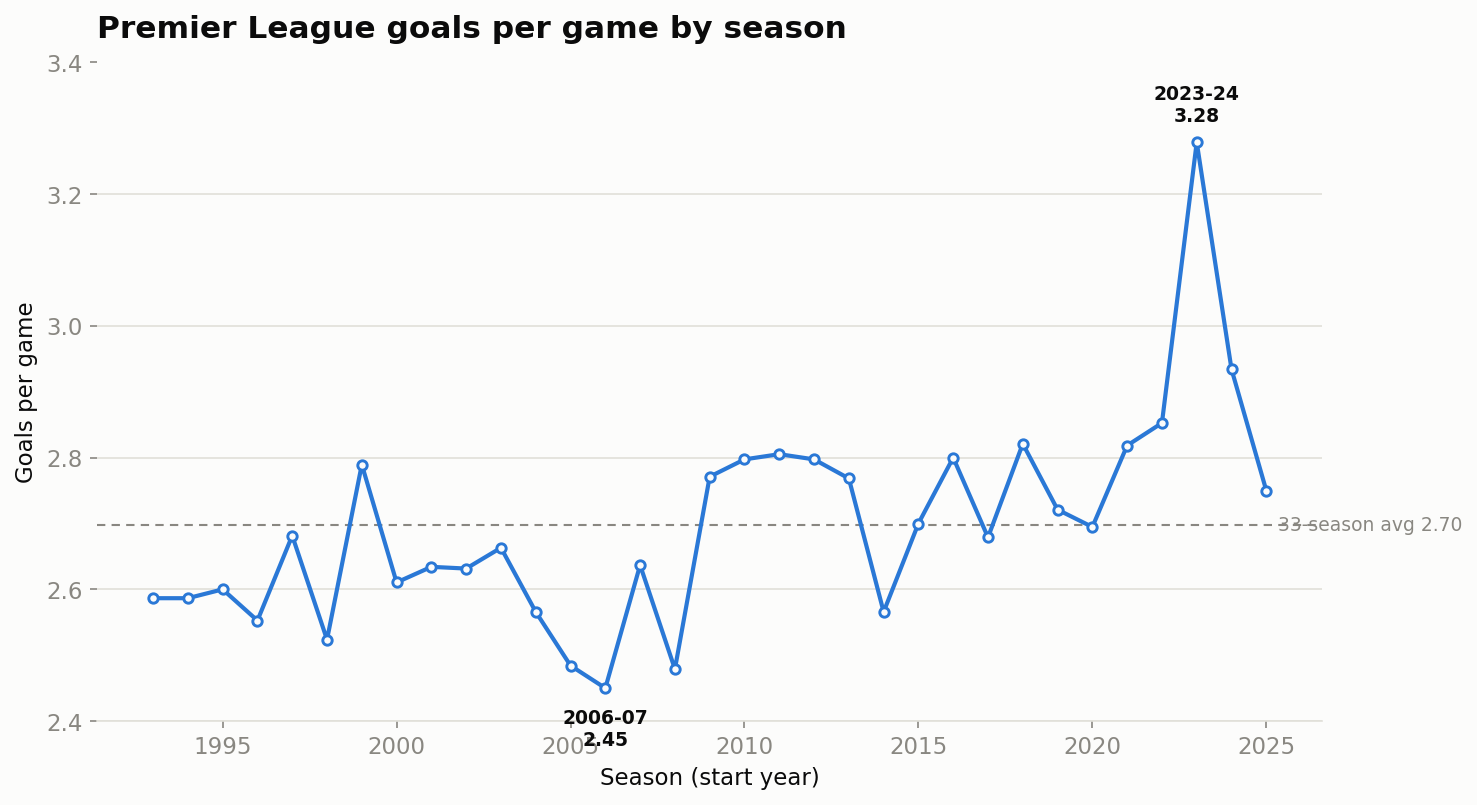

In [4]:
# average goals per match, per season
per_season = (
    results.assign(goals=results.fthg + results.ftag)
    .groupby("season")
    .agg(goals_per_game=("goals", "mean"), matches=("goals", "size"))
    .reset_index()
)
per_season["start_year"] = per_season.season.str[:4].astype(int)
per_season = per_season.sort_values("start_year").reset_index(drop=True)

# --- styling (palette: single-hue blue on a light surface) ---
SURFACE, INK, MUTED, GRID, BLUE = "#fcfcfb", "#0b0b0b", "#898781", "#e1e0d9", "#2a78d6"
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11})

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=150)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

x, y = per_season.start_year, per_season.goals_per_game
ax.plot(x, y, color=BLUE, lw=2, marker="o", ms=4.5,
        mfc=SURFACE, mec=BLUE, mew=1.4, zorder=3)

# 33-season average reference line
avg = y.mean()
ax.axhline(avg, color=MUTED, lw=1, ls=(0, (4, 3)), zorder=1)
ax.text(x.max(), avg, f"  33-season avg {avg:.2f}",
        va="center", ha="left", color=MUTED, fontsize=9)

# label the highest- and lowest-scoring seasons
hi = per_season.loc[per_season.goals_per_game.idxmax()]
lo = per_season.loc[per_season.goals_per_game.idxmin()]
for row, dy, va in [(hi, 8, "bottom"), (lo, -10, "top")]:
    ax.annotate(f"{row.season}\n{row.goals_per_game:.2f}",
                (row.start_year, row.goals_per_game),
                textcoords="offset points", xytext=(0, dy),
                ha="center", va=va, fontsize=9, color=INK, fontweight="bold")

ax.set_title("Premier League goals per game by season",
             fontsize=15, fontweight="bold", color=INK, pad=12, loc="left")
ax.set_ylabel("Goals per game", color=INK)
ax.set_xlabel("Season (start year)", color=INK)
ax.set_ylim(2.4, 3.4)
ax.grid(axis="y", color=GRID, lw=0.8, zorder=0)
ax.tick_params(colors=MUTED)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color(GRID)

fig.tight_layout()
fig.savefig("goals_per_season.png", dpi=150, bbox_inches="tight", facecolor=SURFACE)
plt.show()

## Bonus — the odds table

Most public "PL results" datasets stop at scores. This one keeps **every
bookmaker odds column** football-data publishes, renamed clearly by bookmaker.
That includes **opening *and* closing** prices — the raw material for
closing-line analysis. Here are Bet365's 1X2 open vs close for a few 2024-25 games:

In [5]:
odds = pl.load_results_with_odds(season="2024-25")
odds[[
    "date", "home_team", "away_team",
    "bet365_1x2_home", "bet365_1x2_draw", "bet365_1x2_away",
    "bet365_1x2_home_close", "bet365_1x2_draw_close", "bet365_1x2_away_close",
]].head()

,date,home_team,away_team,bet365_1x2_home,bet365_1x2_draw,bet365_1x2_away,bet365_1x2_home_close,bet365_1x2_draw_close,bet365_1x2_away_close
0,2024-08-16,Man United,Fulham,1.60,4.20,5.25,1.67,4.10,5.00
1,2024-08-17,Arsenal,Wolves,1.18,7.50,13.00,1.14,8.50,15.00
2,2024-08-17,Everton,Brighton,2.63,3.30,2.63,3.10,3.40,2.30
3,2024-08-17,Ipswich,Liverpool,8.50,5.50,1.33,8.00,5.75,1.33
4,2024-08-17,Newcastle,Southampton,1.36,5.25,8.00,1.40,5.00,7.00
